# Compare SAEs across sweep parameters (SAEBench)

This notebook loads **every SAE in one of your sweep runs** (e.g. `trained_models/Qwen3-8B/run10`)
and compares the members **against each other** — no pretrained-registry SAE involved. It works for a
**layers** sweep (members `L18, L22, …`), a **k** sweep (members `L24_k32, L24_k64, …`), or a single
run with multiple step checkpoints.

It reports exactly four metrics, all from [SAEBench](https://www.neuronpedia.org/sae-bench/info):

1. **Dead latents** — fraction of SAE features that never fire. For common widths you should get this
   well under 1%.
2. **Sparse probing** — SAEBench's sparse-probing benchmark (probe accuracy on top-k SAE latents
   across 35 binary tasks).
3. **L0 sparsity** — average number of active latents per token.
4. **Cross-entropy loss score** — how well the SAE reconstruction preserves the model's next-token loss
   (1.0 = perfect, 0.0 = zero-ablation).

Everything is driven by the **Parameters** cell: just point `RUN_DIR` at a run.

## Runtime notes

- Run this **inside the ROCm container** (the same env you train in). `sae-bench` is now in
  `requirements.txt`; install with `pip install -r requirements.txt` (it pulls `sae-probes`,
  `scikit-learn`, `xgboost`, and downgrades `pandas` to 2.x — no effect on training).
- **Cost:** the core eval and especially **sparse probing** run forward passes of the full base model
  and download several probing datasets, so a multi-member sweep on an 8B model takes a while. Sparse
  probing loads its **own** copy of the model, so this notebook frees the core-eval model first.
- **Dead latents** need enough tokens to be trustworthy — a latent looks "dead" if it simply never got
  a chance to fire. Raise `N_SPARSITY_BATCHES` if the dead count looks suspiciously high.

## Imports

In [11]:
from IPython import get_ipython  # type: ignore

ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("load_ext", "autoreload")
    ipython.run_line_magic("autoreload", "2")

import gc
import glob
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import torch

from sae_lens import SAE
from sae_lens.saes.sae import TrainingSAE
from sae_lens.training.activations_store import ActivationsStore
from transformer_lens import HookedTransformer

# SAEBench: core metrics (dead latents, L0, CE-loss-score) + sparse probing.
from sae_bench.evals.core.main import run_evals as core_run_evals
from sae_bench.evals.core.eval_config import CoreEvalConfig
from sae_bench.evals.sparse_probing.main import run_eval as sparse_probing_run_eval
from sae_bench.evals.sparse_probing.eval_config import SparseProbingEvalConfig
from sae_bench.sae_bench_utils import general_utils

torch.set_grad_enabled(False)
pd.set_option("display.max_rows", 200)
print("torch:", torch.__version__, "| cuda available:", torch.cuda.is_available())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
torch: 2.7.1+rocm7.2.2.git1dab218d | cuda available: True


## 1. Parameters

Edit these to point at any run you've trained and any matched pretrained SAE.

In [21]:
# === The sweep to compare ====================================================
# Point at ONE run directory from train_interactive.sh. Every SAE inside is
# discovered and compared against the others (layers sweep, k sweep, or a single
# run's step checkpoints).
RUN_DIR = "/wekafs/smerrill/efficient_sae/trained_models/gemma-3-4b-pt/run4"
RUN_DIR = "/wekafs/smerrill/efficient_sae/trained_models/Qwen3-8B/run13"
# Which checkpoint to evaluate for each sweep member. None = the last/largest
# step (e.g. checkpoints/<hash>/final_500000768). Pin a specific checkpoint by
# setting an int or the step-dir name, e.g. 333334528 or "final_500000768".
CHECKPOINT_STEP = None

# === Eval dataset for the core metrics (config-free so it streams cleanly) ===
EVAL_DATASET = "Skylion007/openwebtext"
CONTEXT_SIZE = 128
EVAL_BATCH_SIZE_PROMPTS = 16

# --- Core eval: dead latents / L0 / CE-loss-score ----------------------------
N_RECON_BATCHES = 20       # batches for CE-loss-score
N_SPARSITY_BATCHES = 500   # batches for L0 + feature density (dead latents)
DEAD_LATENT_THRESHOLD = 0.0  # a latent with density <= this (never fired) is "dead"

# --- Sparse probing ----------------------------------------------------------
SP_K_VALUES = [1, 2, 5]    # number of top SAE latents the probe trains on
SP_LLM_BATCH_SIZE = 16
SP_OUTPUT_DIR = Path(RUN_DIR) / "eval_results" / "sparse_probing"

# Sparse probing is slow because it runs the full base model over every probing
# dataset (train+test) to collect activations. Cap how many datasets to use to
# trade coverage for speed. SAEBench ships 8 datasets by default, so set
# SP_MAX_DATASETS = None to use all of them.
SP_MAX_DATASETS = 1
SP_DATASET_NAMES = SparseProbingEvalConfig().dataset_names
if SP_MAX_DATASETS is not None:
    SP_DATASET_NAMES = SP_DATASET_NAMES[:SP_MAX_DATASETS]

# Examples per dataset that get a base-model forward pass. These dominate the
# runtime, so shrinking them is the other big speed lever (defaults: 4000/1000).
SP_PROBE_TRAIN_SET_SIZE = 2000
SP_PROBE_TEST_SET_SIZE = 500

# === Hardware ================================================================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
# Keep the model + SAEs in the SAME dtype to avoid hook dtype mismatches.
# bf16 keeps the 8B model ~16GB; use "float32" for max precision.
DTYPE = "bfloat16"

print(f"run_dir = {RUN_DIR}")
print(f"device  = {DEVICE} | dtype = {DTYPE}")
print(f"eval dataset = {EVAL_DATASET} (ctx {CONTEXT_SIZE})")

run_dir = /wekafs/smerrill/efficient_sae/trained_models/Qwen3-8B/run13
device  = cuda | dtype = bfloat16
eval dataset = Skylion007/openwebtext (ctx 128)


## 2. Discover the sweep-member SAEs

We scan `RUN_DIR` for every `sae_weights.safetensors`, group them by sweep member, and keep the **final**
checkpoint (largest step) of each. Each member is labelled from its own `cfg.json` (hook layer, and `k`
for TopK), so labels are meaningful for both layouts:

- sweep: `<run>/checkpoints/<id>/<ckpt>/<key>/`
- single: `<run>/L<layer>/<wandb_id>/<step>/`

In [22]:
run_dir = Path(RUN_DIR)
run_cfg_path = run_dir / "config.json"
run_config = json.loads(run_cfg_path.read_text()) if run_cfg_path.exists() else {}


def _step_of(weights_path: Path) -> int:
    """Training step for a checkpoint, read from the nearest ancestor dir whose
    name encodes a step ('final_500000768', '333334528', ...).

    The step lives in an ancestor of the member dir (.../<step>/L17/), not in the
    leaf member dir itself, so we walk up from the weights file and take the
    first step-like path component. Returns -1 when there's none (e.g. a single
    exported SAE), which is fine since dedup then falls back to label only."""
    for part in reversed(weights_path.parts):
        m = re.fullmatch(r"(?:final_)?(\d+)", part)
        if m:
            return int(m.group(1))
    return -1


def _member_label(weights_path: Path) -> str:
    """A stable, meaningful label for the sweep member a checkpoint belongs to,
    read from the SAE's own cfg.json (hook layer + k) rather than the dir name."""
    cfg = json.loads((weights_path.parent / "cfg.json").read_text())
    hook = cfg.get("metadata", {}).get("hook_name", "")
    lm = re.search(r"blocks\.(\d+)\.", hook)
    layer = lm.group(1) if lm else "?"
    k = cfg.get("k")
    return f"L{layer}" + (f"_k{k}" if k is not None else "")


def discover_saes(run_dir: Path, step=None) -> dict[str, Path]:
    """Map sweep-member label -> checkpoint dir for that member.

    By default (``step=None``) the **last/largest-step** checkpoint of each
    member is used (e.g. ``checkpoints/<hash>/final_500000768/L17``). Pass an int
    or a step-dir name (e.g. ``333334528`` or ``"final_500000768"``) to pin a
    specific checkpoint instead.

    Only the canonical training checkpoints are scanned. A run dir also holds
    derived copies of every member -- top-level exported SAEs (``run_dir/L17``)
    and the inference cache written by this notebook (``eval_results/
    inference_saes/...``). Those copies are converted to jumprelu and lose the
    ``k`` field, so they'd get a different label than the batchtopk checkpoint
    (``L17`` vs ``L17_k32``) and each member would show up twice. Scanning only
    the checkpoints tree keeps one stable label per member. (Conversion to an
    inference SAE still happens later in ``load_inference_sae``.)
    """
    search_root = run_dir / "checkpoints" if (run_dir / "checkpoints").exists() else run_dir
    weights = [
        Path(p)
        for p in glob.glob(str(search_root / "**" / "sae_weights.safetensors"), recursive=True)
        if "eval_results" not in Path(p).parts
    ]
    if not weights:
        raise FileNotFoundError(f"No sae_weights.safetensors found under {run_dir}")

    if step is not None:
        want = _step_of(Path(str(step)))
        weights = [w for w in weights if _step_of(w) == want]
        if not weights:
            raise FileNotFoundError(f"No checkpoint with step {step!r} found under {run_dir}")

    best: dict[str, Path] = {}
    best_step: dict[str, int] = {}
    for w in weights:
        label, s = _member_label(w), _step_of(w)
        if label not in best or s > best_step[label]:
            best[label], best_step[label] = w.parent, s
    return dict(sorted(best.items()))


sae_dirs = discover_saes(run_dir, CHECKPOINT_STEP)

print(f"Run: {run_dir.parent.name}/{run_dir.name}  ({len(sae_dirs)} SAEs to compare)\n")
if run_config:
    print("run-level config.json:")
    print(json.dumps(run_config, indent=2))
print("\nDiscovered SAEs (final checkpoint per member):")
for label, d in sae_dirs.items():
    print(f"  {label:12s} <- {d}")

Run: Qwen3-8B/run13  (5 SAEs to compare)

run-level config.json:
{
  "model": "Qwen/Qwen3-8B",
  "model_short": "Qwen3-8B",
  "dataset": "HuggingFaceFW/fineweb-edu",
  "dataset_config": "sample-10BT",
  "arch": "batchtopk",
  "sweep": "layers",
  "k": 32,
  "layers": "18,22,26,30,34",
  "hook_template": "blocks.{layer}.hook_resid_post",
  "d_in": 4096,
  "d_sae": 65536,
  "expansion": 16,
  "training_tokens": 500000000,
  "training_steps": 244140,
  "lr": "3e-4",
  "lr_warm_up_steps": 0,
  "lr_decay_steps": 48828,
  "lr_scheduler": "constant",
  "batch_size": 2048,
  "context_size": 1024,
  "dtype": "bfloat16",
  "gpu": "0",
  "wandb_project": "efficient_sae-Qwen3-8B",
  "wandb_group": "Qwen3-8B/run13",
  "created": "20260604_002507"
}

Discovered SAEs (final checkpoint per member):
  L18_k32      <- /wekafs/smerrill/efficient_sae/trained_models/Qwen3-8B/run13/checkpoints/d57abfc2/333334528/L18
  L22_k32      <- /wekafs/smerrill/efficient_sae/trained_models/Qwen3-8B/run13/checkpoints/d

## 3. Load the SAEs

Each member loads from disk onto the same device/dtype, then we standardize its config so SAEBench can
read `cfg.hook_name` / `cfg.hook_layer` (SAELens v6 keeps these on `cfg.metadata`).

**BatchTopK note:** SAELens only converts a BatchTopK SAE to its inference form (JumpReLU, using the
learned threshold) at the *final* checkpoint. Intermediate checkpoints are saved with the raw
`batchtopk` training architecture, which `SAE.load_from_disk` can't read. `load_inference_sae` below
handles this transparently: inference-ready architectures load directly; training-only ones are loaded
as a `TrainingSAE` and converted (cached under `<run>/eval_results/inference_saes/`).

In [23]:
INFERENCE_SAE_DIR = Path(RUN_DIR) / "eval_results" / "inference_saes"


def load_inference_sae(ckpt_dir: Path, label: str) -> SAE:
    """Load an SAE for inference.

    Inference-ready architectures (standard, topk, jumprelu, ...) load directly.
    Training-only architectures (e.g. ``batchtopk`` saved in intermediate
    checkpoints) aren't in SAELens' inference registry, so we load them as a
    ``TrainingSAE`` and convert to the inference form (batchtopk -> jumprelu using
    the learned threshold). Converted SAEs are cached so re-runs are cheap.
    """
    try:
        return SAE.load_from_disk(str(ckpt_dir), device=DEVICE, dtype=DTYPE)
    except KeyError:
        pass  # training-only architecture (e.g. batchtopk): convert below

    converted = INFERENCE_SAE_DIR / label
    if not (converted / "cfg.json").exists():
        training_sae = TrainingSAE.load_from_disk(str(ckpt_dir), device=DEVICE, dtype=DTYPE)
        training_sae.save_inference_model(converted)
        del training_sae
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    return SAE.load_from_disk(str(converted), device=DEVICE, dtype=DTYPE)


saes: dict[str, SAE] = {}
for label, d in sae_dirs.items():
    sae = load_inference_sae(d, label)
    # Standardize cfg in-place so SAEBench can read cfg.hook_name / cfg.hook_layer.
    general_utils.load_and_format_sae(label, sae, DEVICE)
    saes[label] = sae

print(f"Loaded {len(saes)} SAEs:\n")
for label, sae in saes.items():
    md = sae.cfg.metadata
    arch = sae.cfg.architecture() if callable(sae.cfg.architecture) else sae.cfg.architecture
    print(f"  {label:12s} {type(sae).__name__:20s} {str(arch):10s} "
          f"d_in={sae.cfg.d_in} d_sae={sae.cfg.d_sae} (x{sae.cfg.d_sae // sae.cfg.d_in})  "
          f"hook={md.hook_name}")

# All members share one base model.
MODEL_NAME = next(iter(saes.values())).cfg.metadata.model_name
print(f"\nbase model = {MODEL_NAME}")

/opt/venv/lib/python3.12/site-packages/sae_lens/saes/sae.py:251: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(


Loaded 5 SAEs:

  L18_k32      JumpReLUSAE          jumprelu   d_in=4096 d_sae=65536 (x16)  hook=blocks.18.hook_resid_post
  L22_k32      JumpReLUSAE          jumprelu   d_in=4096 d_sae=65536 (x16)  hook=blocks.22.hook_resid_post
  L26_k32      JumpReLUSAE          jumprelu   d_in=4096 d_sae=65536 (x16)  hook=blocks.26.hook_resid_post
  L30_k32      JumpReLUSAE          jumprelu   d_in=4096 d_sae=65536 (x16)  hook=blocks.30.hook_resid_post
  L34_k32      JumpReLUSAE          jumprelu   d_in=4096 d_sae=65536 (x16)  hook=blocks.34.hook_resid_post

base model = Qwen/Qwen3-8B


## 4. Load the base model

All members target the same base model, so we load it **once** for the core eval (each member reads
activations at its own hook). Loading an 8B model takes a minute. (Sparse probing later loads its own
copy, so we free this one before running it.)

In [24]:
model_kwargs = dict(next(iter(saes.values())).cfg.metadata.model_from_pretrained_kwargs or {})
print(f"Loading {MODEL_NAME} (dtype={DTYPE}) ... this can take a minute.")
model = HookedTransformer.from_pretrained_no_processing(
    MODEL_NAME, device=DEVICE, dtype=DTYPE, **model_kwargs,
)
print("Model loaded:", model.cfg.model_name, "| n_layers:", model.cfg.n_layers)

Loading Qwen/Qwen3-8B (dtype=bfloat16) ... this can take a minute.


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-8B into HookedTransformer
Model loaded: Qwen3-8B | n_layers: 36


## 5. Core metrics — dead latents, L0, CE-loss-score (SAEBench `core`)

For each member we build an `ActivationsStore` at its hook and run SAEBench's `core` eval. From it we
take:
- **L0** — `sparsity.l0`
- **CE-loss-score** — `model_performance_preservation.ce_loss_score`
- **Dead latents** — features whose `feature_density` is `<= DEAD_LATENT_THRESHOLD` (never fired)

In [25]:
core_config = CoreEvalConfig(
    batch_size_prompts=EVAL_BATCH_SIZE_PROMPTS,
    n_eval_reconstruction_batches=N_RECON_BATCHES,
    n_eval_sparsity_variance_batches=N_SPARSITY_BATCHES,
    compute_ce_loss=True,
    compute_sparsity_metrics=True,
    compute_featurewise_density_statistics=True,
    exclude_special_tokens_from_reconstruction=True,
    dataset=EVAL_DATASET,
    context_size=CONTEXT_SIZE,
    llm_dtype=DTYPE,
    verbose=False,
)

core_results: dict[str, dict] = {}
for label, sae in saes.items():
    print(f"\n=== core eval: {label}  (hook={sae.cfg.hook_name}) ===")
    store = ActivationsStore.from_sae(
        model, sae,
        dataset=EVAL_DATASET,
        context_size=CONTEXT_SIZE,
        store_batch_size_prompts=EVAL_BATCH_SIZE_PROMPTS,
        device=DEVICE,
    )
    all_metrics, feature_metrics = core_run_evals(sae, store, model, core_config, verbose=False)

    fd = np.asarray(feature_metrics.get("feature_density", []), dtype=np.float64)
    n_dead = int((fd <= DEAD_LATENT_THRESHOLD).sum()) if fd.size else 0
    core_results[label] = {
        "l0": float(all_metrics["sparsity"]["l0"]),
        "ce_loss_score": float(all_metrics["model_performance_preservation"]["ce_loss_score"]),
        "n_features": int(fd.size),
        "n_dead": n_dead,
        "dead_pct": (100.0 * n_dead / fd.size) if fd.size else float("nan"),
        "feature_density": fd,
    }
    r = core_results[label]
    print(f"  L0={r['l0']:.2f}  CE-loss-score={r['ce_loss_score']:.4f}  "
          f"dead={r['n_dead']}/{r['n_features']} ({r['dead_pct']:.3f}%)")
    del store
    gc.collect()
    torch.cuda.empty_cache()


=== core eval: L18_k32  (hook=blocks.18.hook_resid_post) ===


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

/opt/venv/lib/python3.12/site-packages/sae_lens/training/activations_store.py:455: UserWarning: Dataset is not tokenized. Pre-tokenizing will improve performance and allows for more control over special tokens. See https://decoderesearch.github.io/SAELens/training_saes/#pretokenizing-datasets for more info.
  warnings.warn(


  L0=153.03  CE-loss-score=0.9635  dead=1762/65536 (2.689%)

=== core eval: L22_k32  (hook=blocks.22.hook_resid_post) ===


...

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

  L0=134.15  CE-loss-score=0.9599  dead=362/65536 (0.552%)

=== core eval: L34_k32  (hook=blocks.34.hook_resid_post) ===


Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/80 [00:00<?, ?it/s]

  L0=218.82  CE-loss-score=0.9544  dead=996/65536 (1.520%)


## 6. Sparse probing (SAEBench)

SAEBench's sparse-probing benchmark encodes inputs through each SAE, mean-pools over tokens, selects the
top-`k` latents by mean difference, trains a logistic-regression probe, and reports test accuracy across
35 binary tasks (bias_in_bios, amazon reviews, github, ag_news, europarl). Higher is better; the LLM
residual-stream probe accuracy is reported alongside as a baseline.

`run_eval` loads its **own** copy of the base model, so we free the core-eval model first. This step
downloads the probing datasets and is the slowest part of the notebook.

In [26]:
# Sparse probing loads its OWN copy of the base model, so free ours first.
try:
    del model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

sp_config = SparseProbingEvalConfig(
    model_name=MODEL_NAME,
    llm_dtype=DTYPE,
    llm_batch_size=SP_LLM_BATCH_SIZE,
    k_values=SP_K_VALUES,
    dataset_names=SP_DATASET_NAMES,
    probe_train_set_size=SP_PROBE_TRAIN_SET_SIZE,
    probe_test_set_size=SP_PROBE_TEST_SET_SIZE,
)
print(f"Sparse probing over {len(sp_config.dataset_names)} dataset(s): {sp_config.dataset_names}")
print(f"  train/test examples per dataset: {sp_config.probe_train_set_size}/{sp_config.probe_test_set_size}")
selected_saes = [(label, sae) for label, sae in saes.items()]

SP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sp_raw = sparse_probing_run_eval(
    sp_config,
    selected_saes,
    device=DEVICE,
    output_path=str(SP_OUTPUT_DIR),
    force_rerun=True,
    clean_up_activations=True,
    save_activations=False,
)

# Headline sparse-probing accuracy (top-k SAE latents) + the LLM baseline.
sparse_probing_results: dict[str, dict] = {}
for label in saes:
    metrics = sp_raw[f"{label}_custom_sae"]["eval_result_metrics"]
    sae_m, llm_m = metrics["sae"], metrics["llm"]
    sparse_probing_results[label] = {
        **{f"sae_top_{k}_acc": sae_m.get(f"sae_top_{k}_test_accuracy") for k in SP_K_VALUES},
        **{f"llm_top_{k}_acc": llm_m.get(f"llm_top_{k}_test_accuracy") for k in SP_K_VALUES},
    }
    r = sparse_probing_results[label]
    print(f"  {label:12s} " + "  ".join(
        f"top{k}: SAE={r[f'sae_top_{k}_acc']:.3f} (LLM {r[f'llm_top_{k}_acc']:.3f})"
        for k in SP_K_VALUES))

Sparse probing over 1 dataset(s): ['LabHC/bias_in_bios_class_set1']
  train/test examples per dataset: 2000/500


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

Loaded pretrained model Qwen/Qwen3-8B into HookedTransformer


100%|██████████| 28/28 [00:00<00:00, 435.97it/s]

100%|██████████| 28/28 [00:00<00:00, 674.12it/s]


Removing 17 from test set
Removing 16 from test set
Removing 3 from test set
Removing 4 from test set


...

Num non-zero elements: 5
Test accuracy for 2: 0.892
Num non-zero elements: 5


/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/opt/venv/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


Test accuracy for 6: 0.994
Num non-zero elements: 5
Test accuracy for 9: 0.94


Running SAE evaluation on all selected SAEs: 100%|██████████| 5/5 [03:40<00:00, 44.20s/it]

  L18_k32      top1: SAE=0.685 (LLM 0.535)  top2: SAE=0.862 (LLM 0.802)  top5: SAE=0.909 (LLM 0.844)
  L22_k32      top1: SAE=0.632 (LLM 0.548)  top2: SAE=0.719 (LLM 0.767)  top5: SAE=0.861 (LLM 0.834)
  L26_k32      top1: SAE=0.824 (LLM 0.788)  top2: SAE=0.892 (LLM 0.808)  top5: SAE=0.898 (LLM 0.888)
  L30_k32      top1: SAE=0.736 (LLM 0.663)  top2: SAE=0.904 (LLM 0.761)  top5: SAE=0.903 (LLM 0.891)
  L34_k32      top1: SAE=0.720 (LLM 0.636)  top2: SAE=0.854 (LLM 0.711)  top5: SAE=0.913 (LLM 0.870)


## 7. Results table

The four metrics, one row per sweep member. `dead_latents_%` lower is better; `CE_loss_score` and the
sparse-probing accuracy higher is better; `L0` is the achieved sparsity (interpret relative to your
target, not as "higher/lower better").

In [27]:
SP_MAIN_K = SP_K_VALUES[0]  # headline sparse-probing k (top-1 by default)

rows = []
for label in saes:
    c = core_results.get(label, {})
    s = sparse_probing_results.get(label, {})
    rows.append({
        "SAE": label,
        "dead_latents_%": c.get("dead_pct"),
        "n_dead": c.get("n_dead"),
        "L0": c.get("l0"),
        "CE_loss_score": c.get("ce_loss_score"),
        f"sparse_probe_top{SP_MAIN_K}_acc": s.get(f"sae_top_{SP_MAIN_K}_acc"),
        f"llm_top{SP_MAIN_K}_acc": s.get(f"llm_top_{SP_MAIN_K}_acc"),
    })

summary_df = pd.DataFrame(rows).set_index("SAE")
display(summary_df)

,dead_latents_%,n_dead,L0,CE_loss_score,sparse_probe_top1_acc,llm_top1_acc
SAE,,,,,,
L18_k32,2.688599,1762,153.029373,0.963504,0.6848,0.5352
L22_k32,0.897217,588,1139.436523,0.947080,0.6320,0.5480
L26_k32,0.921631,604,121.940659,0.961679,0.8244,0.7876
L30_k32,0.552368,362,134.147858,0.959854,0.7364,0.6628
L34_k32,1.519775,996,218.816650,0.954380,0.7196,0.6364


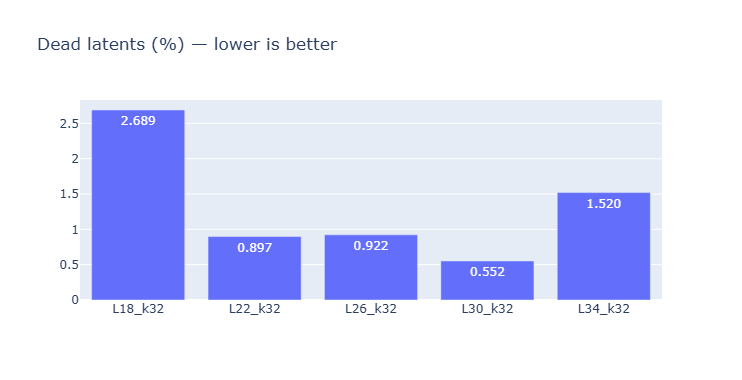

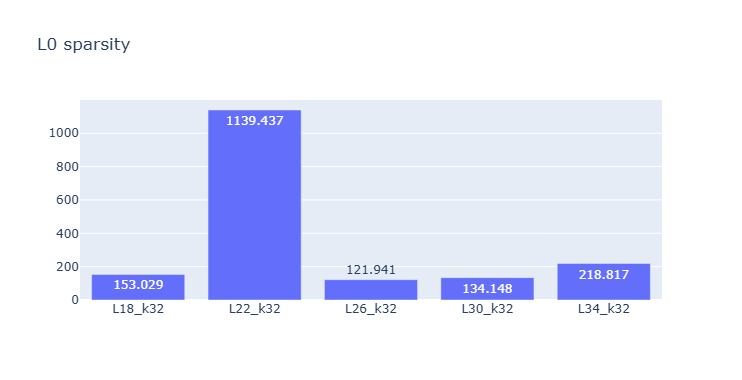

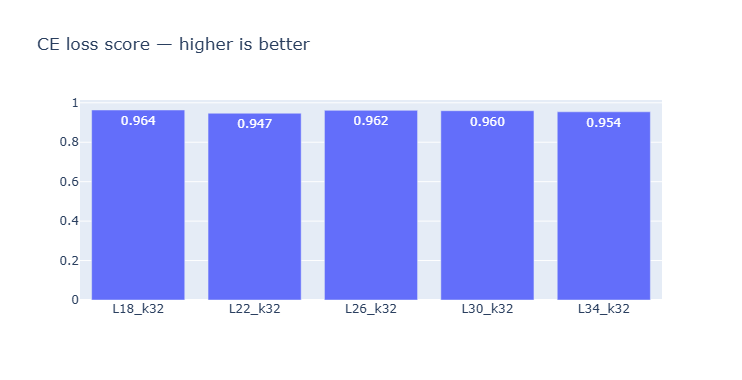

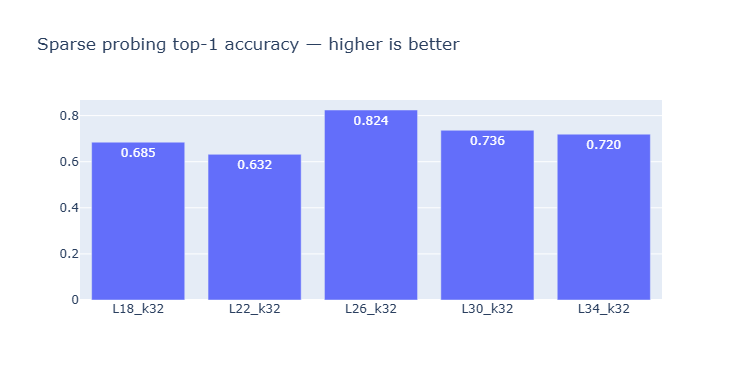

In [28]:
# One bar chart per metric, across sweep members.
bar_specs = [
    ("dead_latents_%", "Dead latents (%) — lower is better"),
    ("L0", "L0 sparsity"),
    ("CE_loss_score", "CE loss score — higher is better"),
    (f"sparse_probe_top{SP_MAIN_K}_acc", f"Sparse probing top-{SP_MAIN_K} accuracy — higher is better"),
]
for col, title in bar_specs:
    if col not in summary_df.columns:
        continue
    sub = summary_df.reset_index()[["SAE", col]].dropna()
    if sub.empty:
        continue
    fig = px.bar(sub, x="SAE", y=col, title=title, text_auto=".3f")
    fig.update_layout(height=380, width=720, xaxis_title="", yaxis_title="")
    fig.show()

## 8. Feature-density histograms (the visual companion to the dead-latent count)

Overlaid **log10 feature-density** histograms across sweep members. A spike at the far left (~ -10) is
the pile of dead features; a bump near 0/-1 is dense (often less interpretable) features.

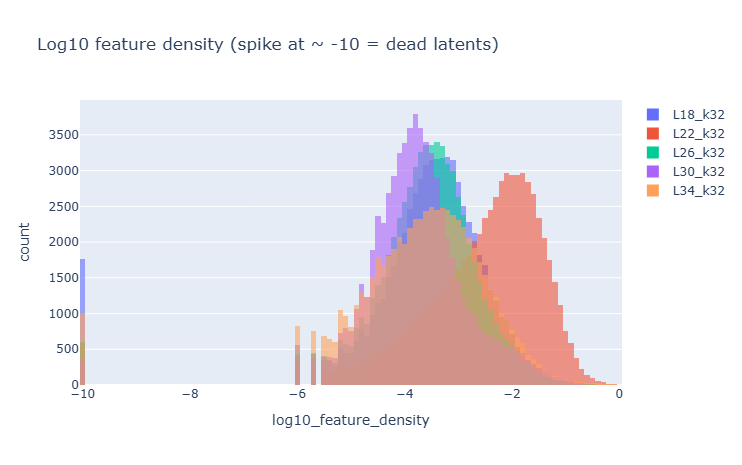

In [29]:
density_frames = []
for label, c in core_results.items():
    fd = c.get("feature_density")
    if fd is None or len(fd) == 0:
        print(f"(no feature_density for {label})")
        continue
    df = pd.DataFrame({"log10_feature_density": np.log10(np.asarray(fd) + 1e-10)})
    df["SAE"] = label
    density_frames.append(df)

if density_frames:
    dens = pd.concat(density_frames, ignore_index=True)
    fig = px.histogram(
        dens, x="log10_feature_density", color="SAE", nbins=100, barmode="overlay",
        opacity=0.6, title="Log10 feature density (spike at ~ -10 = dead latents)",
    )
    fig.update_layout(height=450, width=900, legend_title="")
    fig.show()
else:
    print("No feature-density metrics available to plot.")

## Notes & next steps

- **Reading the comparison:**
  - *Dead latents* — aim for well under 1%. A high count on every member usually means too few eval
    tokens; raise `N_SPARSITY_BATCHES` before concluding the SAE is bad.
  - *CE-loss-score* — closer to 1.0 is better (the SAE reconstruction barely hurts the model).
  - *Sparse probing* — higher SAE accuracy is better; compare against the LLM-baseline column to see how
    much of the linear-probe signal the SAE preserves.
  - *L0* — the achieved sparsity. For a k-sweep this should track your target `k`; use it to read the
    other three metrics along the sparsity axis.
- **Cross-member trends:** for a layers sweep, watch how dead-latent % and sparse-probing accuracy move
  with depth; for a k sweep, watch the sparsity↔fidelity tradeoff (higher k → better CE-loss-score but
  often worse interpretability).
- **Results are cached** under `<run>/eval_results/sparse_probing/` (one JSON per member). Set
  `force_rerun=False` in section 6 to reuse them.
- **More members:** anything `discover_saes` finds is compared automatically — point `RUN_DIR` at a
  different run, or drop more checkpoints into the run directory.